# Curved_Cathode_Example — 弯曲阴极

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Curved_Cathode_Example"
STEM = "astra"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Curved_Cathode_Example | 物理: 弯曲阴极


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Wed Aug 19 21:35:31 

     Working File is:    generator.in                                      
     Initializing       1000      electrons
     including 6 probe particles at standard positions
     Particles start from a cathode
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =       1000
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     2.7738E-02 mm
     vertical beam position            y =     2.0581E-02 mm
     longitudinal beam position        z =     4.9527E-05 m
     horizontal beam size          sig x =      1.000     mm
     vertical beam size            sig y =      1.000     mm
     longitudinal

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: astra.0010.001

  Curved_Cathode_Example @ astra.0010.001
  Particles:           1001 total,      441 active,      0 passive,
                       560 lost,      0 not started
  Total charge:        0.4410 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:       2.1900 MeV/c
  Ref. kinetic E:      1.7378 MeV
  gamma:               4.4008
  beta:              0.973841
----------------------------------------
  Centroid x:         -0.0808 mm
  Centroid y:         -0.0853 mm
  Centroid z:        100.0000 mm
  sigma_x:             2.0698 mm
  sigma_y:             2.0770 mm
  sigma_z:             0.7666 mm
----------------------------------------
  Mean pz:             2.1900 MeV/c
  sigma_p/p:         0.001777
  Mean E_kin:          1.7380 MeV
  sigma_E:             3.7211 keV
  sigma_E/E:         0.002141
----------------------------------------
  eps_x (geom):        2.3839 um.rad
  eps_y (geom):        2.2717 um.rad
  eps_nx:         

quantity,value,unit
n_particle,1001,
n_active,441,
n_passive,0,
n_lost,560,
n_not_started,0,
total_charge_nC,0.441 (|Q|),nC
mean_x_mm,-0.0808138,mm
mean_y_mm,-0.0852659,mm
mean_z_mm,100,mm
sig_x_mm,2.06985,mm


### 示例要点

弯曲阴极发射: Contour.dat 定义阴极轮廓, efld.dat 是阴极表面场表。

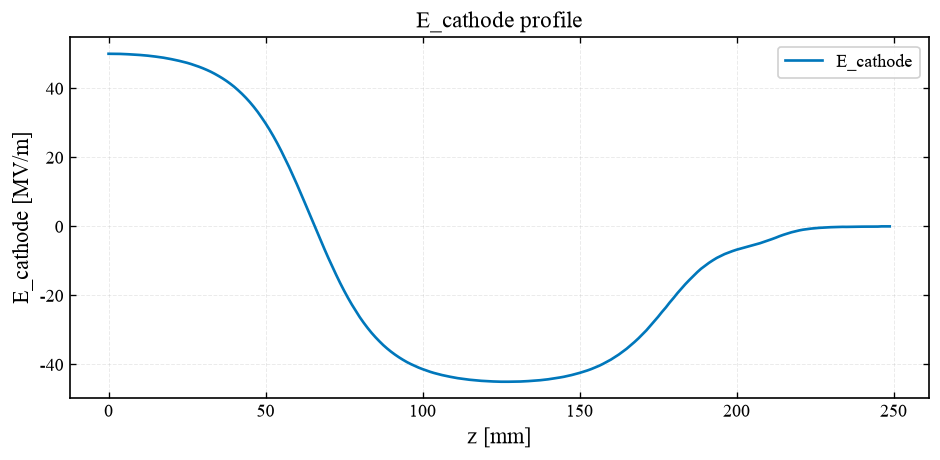

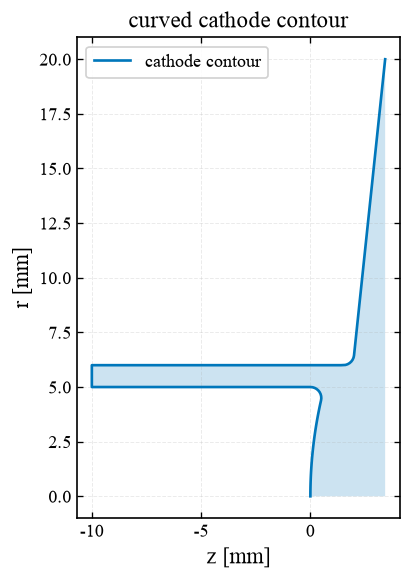

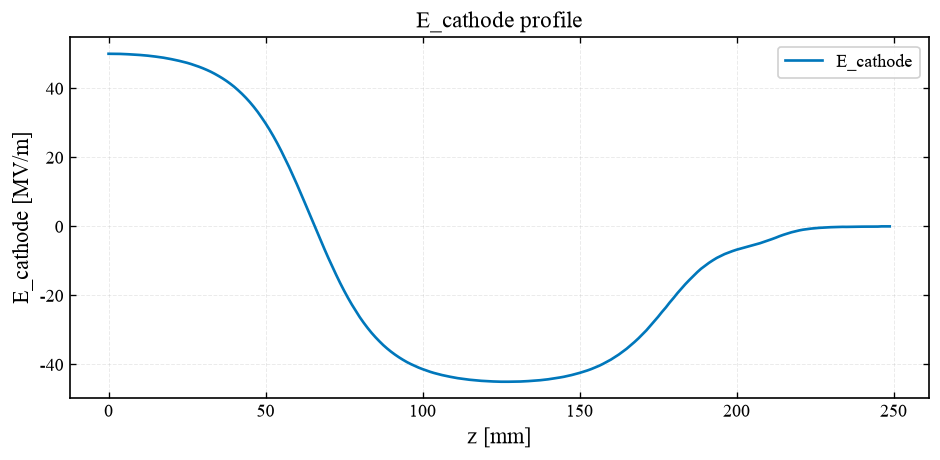

In [5]:
from astra_tools.plot.advanced_plots import (
    plot_curved_cathode_contour, plot_field_profile)
plot_curved_cathode_contour(work / "Contour.dat")
plot_field_profile(work / "efld.dat", label="E_cathode", unit="MV/m")

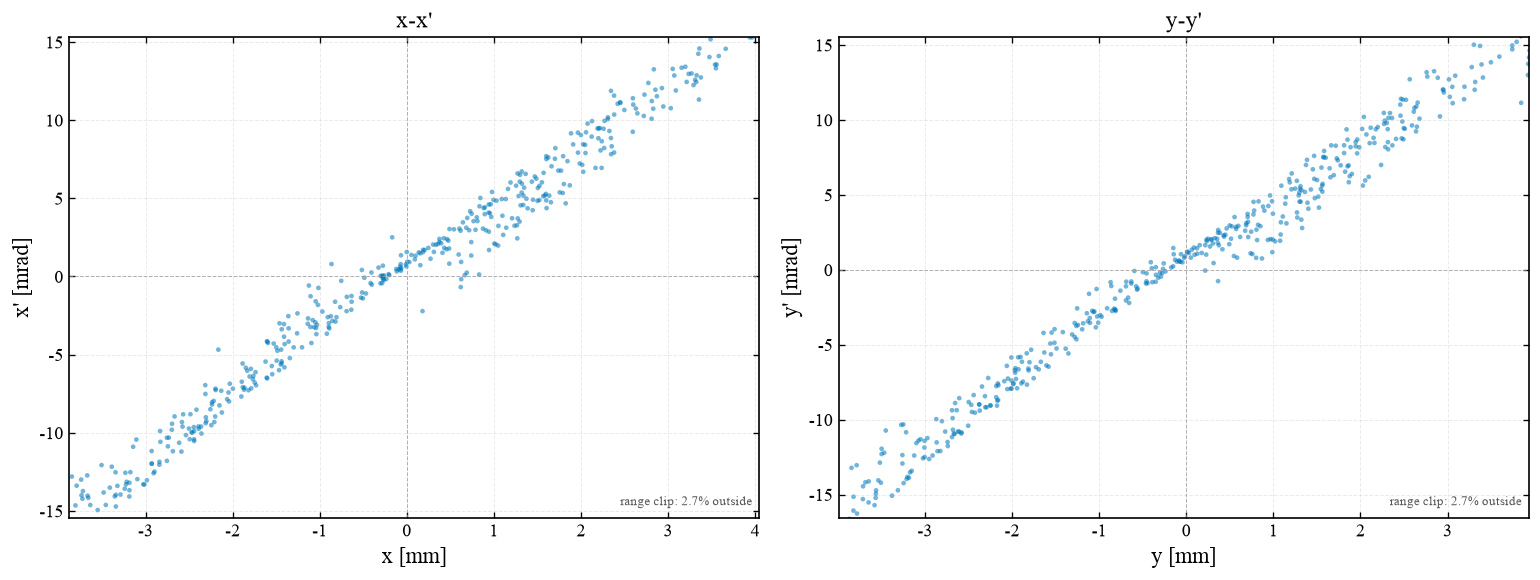

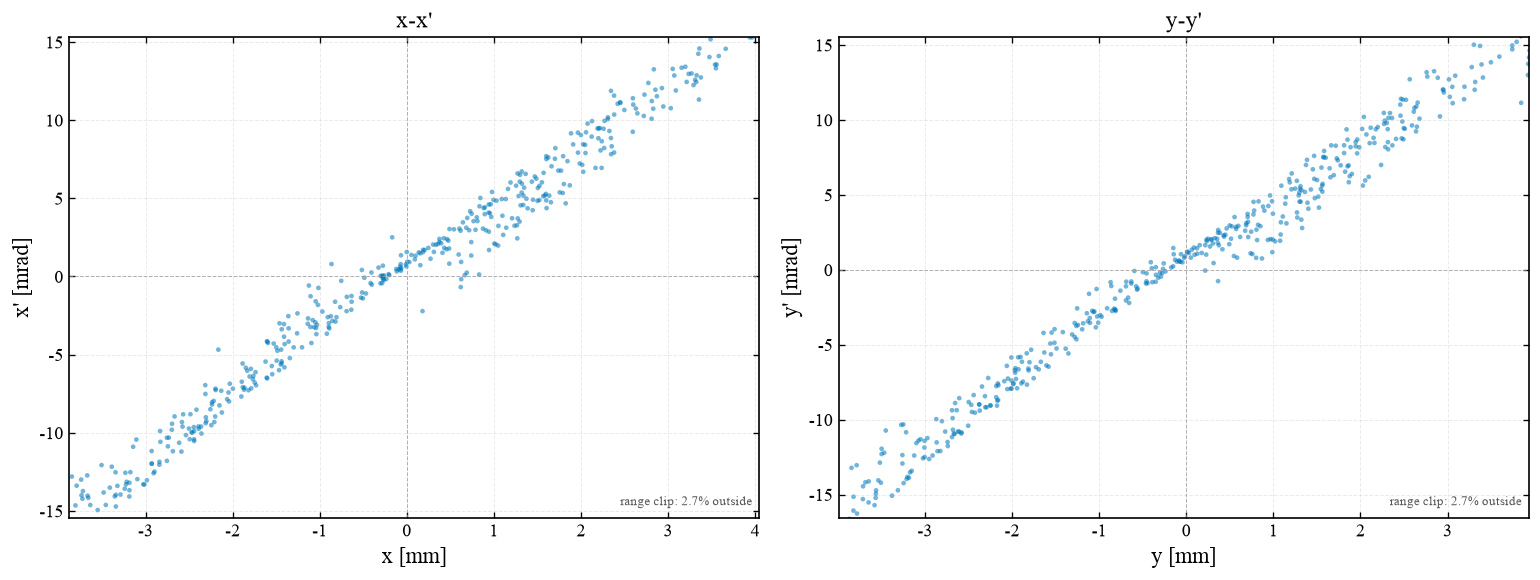

In [6]:
from astra_tools.plot.phase_space import plot_transverse_phase_space
plot_transverse_phase_space(dist)

In [7]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  护栏: Xemit 行数 new=49 golden=49
  护栏: 末行 z=0.1 vs ZSTOP=0.1 (rel=0.0000%)
  末行比对 (new vs golden):
    norm_emit_x    1.0217e-05 1.0217e-05 rel=0.0000% OK
    sigma_x        0.0020698  0.0020698  rel=0.0000% OK
    mean_z         0.1        0.1        rel=0.0000% OK
  总体: OK
其他官方算例的示例 notebook 同样位于 examples/ 目录
